# 주식 분석 프로젝트
주식 분석은 주식 시장에서 개별 주식의 가치를 평가하고, 향후 주가의 움직임을 예측하기 위한 과정입니다. 이 분석은 투자자가 정보에 기반한 결정을 내리는 데 도움을 주어, 보다 체계적이고 과학적인 투자 접근 방식을 취할 수 있게 합니다.

## 저평가 주식 종목 발굴하기
저평가 주식이란 시장에서 그 가치에 비해 낮은 가격으로 거래되고 있는 주식을 의미합니다. 이는 주식의 시장 가격이 회사의 실질적인 경제적 가치, 즉 내재 가치(intrinsic value)보다 낮을 경우에 해당합니다. 저평가는 다양한 원인에 의해 발생할 수 있으며, 이를 정확히 식별하는 것은 투자자에게 매력적인 매수 기회를 제공할 수 있습니다.

### 저평가 주식의 특징과 원인
* 재무 지표: 저평가 주식은 종종 낮은 주가수익비율(P/E), 높은 배당수익률, 낮은 주가순자산비율(P/B) 등의 재무 지표를 가지고 있습니다.
* 시장의 간과: 때때로 시장 참여자들이 회사의 잠재력을 간과하거나, 특정 산업이나 회사에 대한 일시적인 부정적인 감정 때문에 주가가 저평가될 수 있습니다.
* 경제적 변동성: 경제 불확실성 또는 시장 변동성이 증가할 때, 투자자들은 위험 자산을 피하려고 할 수 있으며, 이러한 상황에서도 견고한 재무 기반을 가진 주식이 저평가될 수 있습니다.
* 임시적인 문제: 회사가 임시적인 문제를 겪고 있어 그 가치가 잠시 하락했을 수 있습니다. 이러한 문제가 해결되면 주식은 다시 적정 가치를 회복할 수 있습니다.

### 네이버 증권을 통해 주식 정보 가져오기

In [1]:
from datetime import datetime, timedelta
from bs4 import BeautifulSoup
from io import StringIO
from tqdm import tqdm
from numpy import nan

import pandas as pd
import requests
import random
import time

In [2]:
url = requests.get("https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page=1")
url

<Response [200]>

In [3]:
html = BeautifulSoup(url.text)
html

<!--  global include --><html lang="ko">
<head>
<title>시가총액 : 네이버페이 증권</title>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="text/javascript" http-equiv="Content-Script-Type"/>
<meta content="text/css" http-equiv="Content-Style-Type"/>
<meta content="네이버페이 증권" name="apple-mobile-web-app-title"/>
<meta content="http://finance.naver.com/sise/sise_market_sum.naver" property="og:url"/>
<meta content="시가총액 : 네이버페이 증권" property="og:title"/>
<meta content="관심종목의 실시간 주가를 가장 빠르게 확인하는 곳" property="og:description"/>
<meta content="https://ssl.pstatic.net/static/m/stock/im/2016/08/og_stock-200.png" property="og:image"/>
<meta content="article" property="og:type"/>
<meta content="" property="og:article:thumbnailUrl"/>
<meta content="네이버페이 증권" property="og:article:author"/>
<meta content="http://FINANCE.NAVER.COM" property="og:article:author:url"/>
<link href="https://ssl.pstatic.net/imgstock/static.pc/20240618155848/css/finance_header.css" rel="stylesheet" type

In [4]:
table = html.find("table", class_ = 'type_2')
table

<table cellpadding="0" cellspacing="0" class="type_2" summary="코스피 시세정보를 선택한 항목에 따라 정보를 제공합니다.">
<caption>코스피</caption>
<colgroup>
<col width="2%"/>
<col width="*"/>
<col width="7%"/>
<col width="9%"/>
<col width="7%"/>
<col width="8%"/>
<col width="8%"/>
<col width="8%"/>
<col width="8%"/>
<col width="8%"/>
<col width="8%"/>
<col width="8%"/>
<col width="6%"/>
</colgroup>
<thead>
<tr>
<th scope="col">N</th>
<th scope="col">종목명</th>
<th scope="col">현재가</th>
<th class="tr" scope="col" style="padding-right:8px">전일비</th>
<th scope="col">등락률</th>
<th scope="col">액면가</th>
<th scope="col">시가총액</th>
<th scope="col">상장주식수</th>
<th scope="col">외국인비율</th>
<th scope="col">거래량</th>
<th scope="col">PER</th>
<th scope="col">ROE</th>
<th scope="col">토론실</th>
</tr>
</thead>
<tbody>
<tr><td class="blank_08" colspan="10"></td></tr>
<tr onmouseout="mouseOut(this)" onmouseover="mouseOver(this)">
<td class="no">1</td>
<td><a class="tltle" href="/item/main.naver?code=005930">삼성전자</a></td>
<td class="number"

In [5]:
table_str = str(table)
table_io = StringIO(table_str)

tables = pd.read_html(table_io)[0]
tables = tables[tables['종목명'].notnull()]

tables = tables.drop(['N', '토론실'], axis = 1)
tables.head()

,종목명,현재가,전일비,등락률,액면가,시가총액,상장주식수,외국인비율,거래량,PER,ROE
1,삼성전자,81700.0,"상승 1,100",+1.36%,100.0,4877312.0,5969783.0,55.77,9762647.0,28.18,4.15
2,SK하이닉스,224000.0,"상승 1,000",+0.45%,5000.0,1630725.0,728002.0,56.11,3738816.0,-35.35,-15.61
3,LG에너지솔루션,333000.0,"상승 2,000",+0.60%,500.0,779220.0,234000.0,4.86,67297.0,105.85,6.36
4,현대차,288500.0,"상승 7,500",+2.67%,5000.0,604166.0,209416.0,40.86,709952.0,6.66,13.68
5,삼성전자우,64700.0,보합0,0.00%,100.0,532408.0,822887.0,75.61,842972.0,22.32,NaN


In [6]:
kospi_box = []
for n in tqdm(range(1, 45)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page={n}")
    html = BeautifulSoup(url.text)
    
    table = html.find("table", class_ = 'type_2')
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]

    tables = tables.drop(['N', '토론실'], axis = 1)
    tables['소속'] = 'KOSPI'
    kospi_box.append(tables)
    time.sleep(1)
    
kosdaq_box = []
for n in tqdm(range(1, 36)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=1&page={n}")
    html = BeautifulSoup(url.text)
    
    table = html.find("table", class_ = 'type_2')
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]

    tables = tables.drop(['N', '토론실'], axis = 1)
    tables['소속'] = 'KOSDAQ'
    kosdaq_box.append(tables)
    time.sleep(1)
    
stock = pd.concat(kospi_box + kosdaq_box, ignore_index=True)
stock

100%|██████████████████████████████████████████████████████████████████████████████████| 35/35 [00:45<00:00,  1.29s/it]


,종목명,현재가,전일비,등락률,액면가,시가총액,상장주식수,외국인비율,거래량,PER,ROE,소속
0,삼성전자,81700.0,"상승 1,100",+1.36%,100.0,4877312.0,5969783.0,55.77,9770441.0,28.18,4.15,KOSPI
1,SK하이닉스,224000.0,"상승 1,000",+0.45%,5000.0,1630725.0,728002.0,56.11,3742700.0,-35.35,-15.61,KOSPI
2,LG에너지솔루션,332500.0,"상승 1,500",+0.45%,500.0,778050.0,234000.0,4.86,67349.0,105.69,6.36,KOSPI
3,현대차,288500.0,"상승 7,500",+2.67%,5000.0,604166.0,209416.0,40.86,710300.0,6.66,13.68,KOSPI
4,삼성전자우,64700.0,보합0,0.00%,100.0,532408.0,822887.0,75.61,843378.0,22.32,NaN,KOSPI
...,...,...,...,...,...,...,...,...,...,...,...,...
3932,엔에이치스팩25호,2345.0,상승 15,+0.64%,100.0,71.0,3020.0,0.07,6940.0,45.98,2.73,KOSDAQ
3933,하나32호스팩,2210.0,하락 5,-0.23%,100.0,71.0,3200.0,1.92,3755.0,NaN,NaN,KOSDAQ
3934,에스케이증권제12호스팩,2115.0,보합0,0.00%,100.0,70.0,3310.0,0.20,4492.0,NaN,NaN,KOSDAQ
3935,소프트센우,9300.0,상승 280,+3.10%,200.0,33.0,357.0,0.21,2151.0,-90.29,NaN,KOSDAQ


### 저 PER 주식 찾기
PER (Price to Earnings Ratio, 주가수익비율)은 주식의 현재 가격을 주당 순이익(Earnings per Share, EPS)으로 나눈 비율입니다. PER은 투자자들이 해당 주식의 가치를 평가하는 데 중요한 지표로 사용됩니다.

In [7]:
sample = stock.dropna(subset = "PER")
sample = sample[(sample['PER'] > 0) & (sample['PER'] < 10)]
sample = sample.sort_values("PER")

for i in range(len(sample)):
    
    data = sample.iloc[i]
    
    name = data['종목명']
    per = data['PER']
    
    print(f"{name} PER : {per}")

현대지에프홀딩스 PER : 0.49
KC그린홀딩스 PER : 0.54
동국홀딩스 PER : 0.9
흥국화재 PER : 0.95
다산솔루에타 PER : 0.99
씨엑스아이 PER : 1.06
유성티엔에스 PER : 1.23
엔케이 PER : 1.26
지역난방공사 PER : 1.34
상지건설 PER : 1.34
로스웰 PER : 1.36
엠벤처투자 PER : 1.38
솔루스첨단소재1우 PER : 1.4
흥국화재우 PER : 1.46
AP헬스케어 PER : 1.47
한라IMS PER : 1.63
한일사료 PER : 1.7
IHQ PER : 1.71
태원물산 PER : 1.88
서희건설 PER : 1.9
서연 PER : 1.94
삼목에스폼 PER : 1.95
바이브컴퍼니 PER : 1.97
세방우 PER : 1.97
넥스틸 PER : 1.97
슈프리마에이치큐 PER : 2.01
티에이치엔 PER : 2.18
매일홀딩스 PER : 2.2
광무 PER : 2.23
넥센우 PER : 2.25
일지테크 PER : 2.33
세아제강 PER : 2.34
계룡건설 PER : 2.37
한신공영 PER : 2.37
SG&G PER : 2.39
동국제강 PER : 2.41
OCI홀딩스 PER : 2.43
삼정펄프 PER : 2.5
넥센타이어1우B PER : 2.6
SK디앤디 PER : 2.6
한국캐피탈 PER : 2.6
지란지교시큐리티 PER : 2.65
미창석유 PER : 2.72
대한제분 PER : 2.72
삼양홀딩스우 PER : 2.72
삼양사우 PER : 2.74
액토즈소프트 PER : 2.75
성신양회 PER : 2.77
서원 PER : 2.77
세동 PER : 2.77
한화손해보험 PER : 2.8
GS우 PER : 2.85
에어부산 PER : 2.86
NI스틸 PER : 2.88
한국무브넥스 PER : 2.88
DN오토모티브 PER : 2.88
동양이엔피 PER : 2.88
세중 PER : 2.88
진흥기업 PER : 2.89
삼보판지 PER : 2.89
솔본 PER : 

### 고 ROE 주식 찾기
ROE (Return on Equity, 자기자본이익률)는 기업의 자기자본을 사용하여 얼마나 효율적으로 이익을 창출하는지를 나타내는 재무 비율입니다. ROE는 주주들이 투자한 자본 대비 기업이 얼마나 많은 이익을 내고 있는지를 평가하는 데 사용됩니다.

In [8]:
sample = stock.dropna(subset = "ROE")
sample = sample[sample['ROE'] > 0]
sample = sample.sort_values("ROE", ascending = False)

for i in range(len(sample)):
    
    data = sample.iloc[i]
    
    name = data['종목명']
    per = data['ROE']
    
    print(f"{name} ROE : {per}")

현대사료 ROE : 3775.29
코다코 ROE : 907.99
대유플러스 ROE : 556.76
셀리버리 ROE : 472.6
위니아 ROE : 208.56
엔젤로보틱스 ROE : 166.35
바이젠셀 ROE : 150.62
이에이트 ROE : 124.68
시스웍 ROE : 116.23
진에어 ROE : 112.52
한일사료 ROE : 109.57
파로스아이바이오 ROE : 101.81
티웨이항공 ROE : 91.56
아이엠비디엑스 ROE : 91.33
아이씨티케이 ROE : 83.16
바이브컴퍼니 ROE : 82.83
HD현대마린솔루션 ROE : 71.59
에어부산 ROE : 66.45
동운아나텍 ROE : 64.09
제룡전기 ROE : 57.64
한미반도체 ROE : 55.54
다산솔루에타 ROE : 55.28
큐로셀 ROE : 55.22
한라IMS ROE : 55.21
에이피알 ROE : 54.88
현대지에프홀딩스 ROE : 49.81
원텍 ROE : 49.68
오상헬스케어 ROE : 47.25
비올 ROE : 44.89
제주항공 ROE : 44.86
밀리의서재 ROE : 44.55
IHQ ROE : 43.12
상지건설 ROE : 43.07
엔케이 ROE : 41.19
HB솔루션 ROE : 40.57
엘앤씨바이오 ROE : 39.5
F&F ROE : 38.43
감성코퍼레이션 ROE : 37.53
노브랜드 ROE : 35.93
넥스틸 ROE : 35.49
솔루엠 ROE : 34.83
인카금융서비스 ROE : 34.68
대성홀딩스 ROE : 34.24
에코프로에이치엔 ROE : 34.05
HPSP ROE : 34.05
제이투케이바이오 ROE : 33.76
크레버스 ROE : 33.62
폴라리스오피스 ROE : 33.22
명신산업 ROE : 33.22
삐아 ROE : 32.93
실리콘투 ROE : 32.86
하나투어 ROE : 32.03
케이에스피 ROE : 31.81
에스와이스틸텍 ROE : 31.57
삼영 ROE : 31.45
한국쉘석유 ROE : 31.

## 고 배당주 발굴하기
배당주(Dividend Stock)는 기업이 주주들에게 정기적으로 배당금을 지급하는 주식을 말합니다. 배당주는 투자자들에게 주식 가격 상승 뿐만 아니라 배당금이라는 형태로 정기적인 수익을 제공하는 특징이 있습니다. 배당주는 일반적으로 안정적이고 성숙한 기업에서 발행됩니다.

In [9]:
from bs4 import BeautifulSoup
from io import StringIO
import requests
import pandas as pd
import time

url = requests.get("https://finance.naver.com/sise/dividend_list.naver?&page=1")
html = BeautifulSoup(url.text)

table = html.find("table", class_ = "type_1 tb_ty")
table = StringIO(str(table))
table = pd.read_html(table, header = 1)[0]
table.dropna(subset = "종목명", inplace = True)
table

,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
1,한국패러랠,240.0,23.12,2168.0,903.33,-,-,-,-,390.0,90,235
2,스타에스엠리츠,3110.0,23.12,961.0,30.90,220.22,5.24,26.77,1.51,1572.0,200,150
3,예스코홀딩스,45550.0,23.12,8750.0,19.21,157.91,4.99,8.38,0.30,2500.0,2250,2000
4,에이블씨엔씨,9710.0,24.04,1427.0,14.70,605.02,6.05,28.98,2.01,0.0,0,0
5,오상헬스케어,14880.0,23.12,2000.0,13.44,21.62,47.25,-,0.00,3000.0,1000,2000
8,신한알파리츠,6170.0,24.03,828.0,13.42,727.40,1.68,76.30,1.14,372.0,352,302
9,NH프라임리츠,4330.0,23.11,531.0,12.26,58.40,12.18,6.12,0.71,225.0,248,246
10,크레버스,18060.0,23.12,2000.0,11.07,110.97,33.62,12.71,3.15,1800.0,2000,800
11,정다운,2960.0,23.12,300.0,10.14,30.04,30.34,2.80,0.75,100.0,100,0
12,마스턴프리미어리츠,2550.0,24.03,239.0,9.37,-20.96,-9.01,-7.18,0.72,263.0,-,-


In [10]:
from tqdm import tqdm

total = []

for n in tqdm(range(1, 28)):

    url = requests.get(f"https://finance.naver.com/sise/dividend_list.naver?&page={n}")
    html = BeautifulSoup(url.text)
    
    table = html.find("table", class_ = "type_1 tb_ty")
    table = StringIO(str(table))
    table = pd.read_html(table, header = 1)[0]
    table.dropna(subset = "종목명", inplace = True)
    total.append(table)
    time.sleep(1)

total_table = pd.concat(total, ignore_index=True)
total_table

100%|██████████████████████████████████████████████████████████████████████████████████| 27/27 [00:35<00:00,  1.33s/it]


,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
0,한국패러랠,240.0,23.12,2168.0,903.33,-,-,-,-,390.0,90,235
1,스타에스엠리츠,3110.0,23.12,961.0,30.90,220.22,5.24,26.77,1.51,1572.0,200,150
2,예스코홀딩스,45550.0,23.12,8750.0,19.21,157.91,4.99,8.38,0.30,2500.0,2250,2000
3,에이블씨엔씨,9710.0,24.04,1427.0,14.70,605.02,6.05,28.98,2.01,0.0,0,0
4,오상헬스케어,14880.0,23.12,2000.0,13.44,21.62,47.25,-,0.00,3000.0,1000,2000
...,...,...,...,...,...,...,...,...,...,...,...,...
1302,주성엔지니어링,33900.0,23.12,50.0,0.15,6.95,6.8,48.53,3.14,193.0,155.0,0
1303,에프에스티,36850.0,23.12,50.0,0.14,-7.23,-5.61,-39.58,2.02,100.0,130.0,100
1304,삼아알미늄,74900.0,23.12,100.0,0.13,43.19,1.73,451.3,6.14,250.0,200.0,100
1305,포스코퓨처엠,255500.0,24.03,250.0,0.10,67.39,1.19,968.22,11.83,300.0,300.0,285


In [11]:
total_table.sort_values("수익률 (%)", ascending = False)

,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
0,한국패러랠,240.0,23.12,2168.0,903.33,-,-,-,-,390.0,90,235
1,스타에스엠리츠,3110.0,23.12,961.0,30.90,220.22,5.24,26.77,1.51,1572.0,200,150
2,예스코홀딩스,45550.0,23.12,8750.0,19.21,157.91,4.99,8.38,0.30,2500.0,2250,2000
3,에이블씨엔씨,9710.0,24.04,1427.0,14.70,605.02,6.05,28.98,2.01,0.0,0,0
4,오상헬스케어,14880.0,23.12,2000.0,13.44,21.62,47.25,-,0.00,3000.0,1000,2000
...,...,...,...,...,...,...,...,...,...,...,...,...
1302,주성엔지니어링,33900.0,23.12,50.0,0.15,6.95,6.8,48.53,3.14,193.0,155.0,0
1303,에프에스티,36850.0,23.12,50.0,0.14,-7.23,-5.61,-39.58,2.02,100.0,130.0,100
1304,삼아알미늄,74900.0,23.12,100.0,0.13,43.19,1.73,451.3,6.14,250.0,200.0,100
1305,포스코퓨처엠,255500.0,24.03,250.0,0.10,67.39,1.19,968.22,11.83,300.0,300.0,285


### 4년 연속 배당금을 올린 종목 찾기

In [12]:
total_table = total_table.replace("-", 0)
total_table = total_table.dropna(subset = ['배당금', '1년전', '2년전', '3년전'])

total_table['배당금'] = total_table['배당금'].astype(int)
total_table['1년전'] = total_table['1년전'].astype(int)
total_table['2년전'] = total_table['2년전'].astype(int)
total_table['3년전'] = total_table['3년전'].astype(int)

A = total_table['3년전'] < total_table['2년전']
B = total_table['2년전'] < total_table['1년전']
C = total_table['1년전'] < total_table['배당금']

total_table[A & B & C]

,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
2,예스코홀딩스,45550.0,23.12,8750,19.21,157.91,4.99,8.38,0.30,2500,2250,2000
5,신한알파리츠,6170.0,24.03,828,13.42,727.40,1.68,76.30,1.14,372,352,302
11,제이알글로벌리츠,4140.0,23.12,385,9.30,165.86,2.61,34.70,0.94,373,366,147
12,미래에셋맵스리츠,3110.0,23.11,284,9.14,48.98,6.17,10.72,0.66,279,268,129
26,이지스밸류리츠,5130.0,24.02,412,8.03,36.77,7.99,7.99,0.56,351,293,203
...,...,...,...,...,...,...,...,...,...,...,...,...
1242,덴티움,117800.0,23.12,400,0.34,3.57,23.02,15.02,2.43,300,250,200
1254,삼양식품,668000.0,23.12,2100,0.31,12.4,24.81,12.89,2.85,1400,1000,800
1268,솔브레인홀딩스,71800.0,23.12,200,0.28,4.54,7.63,10.21,0.74,170,150,0
1295,한미약품,277000.0,23.12,490,0.18,4.25,16.00,30.88,4.68,481,471,462


## 추천 종목 발굴하기
### FinaaceDataReader를 통한 데이터 수집하기
FinanceDataReader는 주로 금융 데이터를 분석 목적으로 사용되는 파이썬 라이브러리입니다. 이 라이브러리는 다양한 금융 시장의 주식 가격, 지수, 환율 등을 쉽게 가져올 수 있게 해주며, 데이터 수집을 위한 여러 API를 통합하여 사용자가 보다 편리하게 데이터를 이용할 수 있도록 설계되었습니다.

In [14]:
# 아래 코드가 실행이 안될시 FinanceDataReader 라이브러리를 설치하세요.
# pip install finance-datareader

In [13]:
import FinanceDataReader as fdr

# 삼성전자의 2020년 데이터 가져오기
df = fdr.DataReader('005930')
df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2000-03-03,6200,6250,5880,6000,2819891,NaN
2000-03-06,6000,6050,5600,5640,783020,-0.060000
2000-03-07,5600,5640,5480,5620,601414,-0.003546
2000-03-08,5520,6000,5500,5920,649288,0.053381
2000-03-09,5970,5980,5620,5620,1117890,-0.050676
...,...,...,...,...,...,...
2024-06-19,81100,82500,80500,81200,24168863,0.017544
2024-06-20,81500,82200,81200,81600,20288913,0.004926
2024-06-21,80700,80800,80000,80000,17907523,-0.019608


### 단순 이동평균선(MA)
이동평균선(Moving Average, MA)은 주식, 금융, 경제 데이터와 같은 시계열 데이터에서 사용되는 통계적 지표로, 특정 기간 동안의 평균값을 연속적으로 계산함으로써 데이터의 전반적인 추세를 파악하는 데 도움을 줍니다. 이동평균선은 가격 데이터의 "노이즈"를 제거하고, 기본적인 가격 동향이나 방향성을 더 명확하게 보여줍니다.

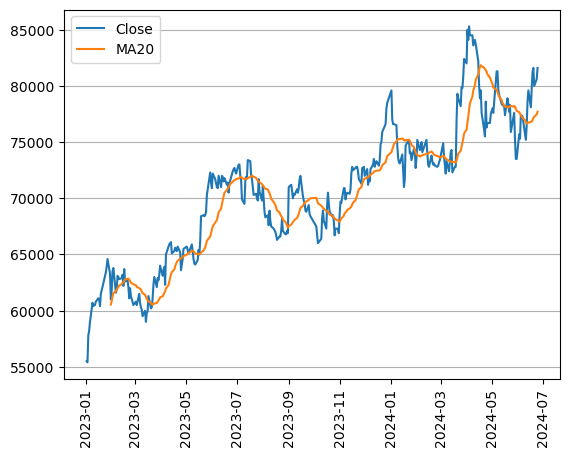

In [15]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df = fdr.DataReader("005930")
df2 = df[df.index.year >= 2023]

df2['MA20'] = df2['Close'].rolling(window = 20).mean()

plt.plot(df2['Close'])
plt.plot(df2['MA20'])
plt.legend(['Close', 'MA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()

### 지수 이동평균선(EMA)
지수 이동평균선(Exponential Moving Average, EMA)은 금융 분석에서 사용되는 이동 평균의 한 형태로, 최근 데이터에 더 큰 가중치를 부여하여 계산합니다. EMA는 단순 이동 평균선(SMA)에 비해 가격 변화에 더 민감하게 반응하며, 이는 EMA가 최근 가격 동향을 더 강조하기 때문입니다.

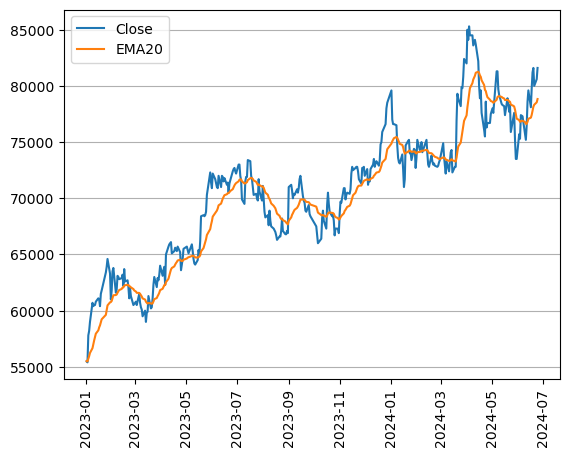

In [16]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

df = fdr.DataReader("005930")
df = df[df.index.year >= 2023]

# 종가를 기반으로 하는 20일 지수 이동 평균(EMA) 계산
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

plt.plot(df['Close'])
plt.plot(df['EMA20'])
plt.legend(['Close', 'EMA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()

### EMA를 활용해서 추천 종목 발굴하기

In [23]:
for i in range(len(stocks)):

    stock = stocks.iloc[i]
    code = stock['Code']
    name = stock['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    
    today_data = df.iloc[-1]
    if today_data['Close'] < today_data['EMA20']:
        print(name)

LG에너지솔루션
삼성바이오로직스
셀트리온
POSCO홀딩스
NAVER
삼성SDI
LG화학
삼성물산
포스코퓨처엠
카카오
에코프로비엠
한국전력
에코프로
삼성에스디에스
SK
삼성전기
KT&G
SK이노베이션
아모레퍼시픽
카카오뱅크
하이브
S-Oil
에코프로머티
HD현대마린솔루션
SK바이오팜
LS ELECTRIC
포스코DX
LG생활건강
한국타이어앤테크놀로지
두산밥캣
엘앤에프
두산로보틱스
한화솔루션
코스모신소재
금양
LS
넷마블
엔켐
한진칼
삼성E&A
삼성카드
현대제철
SK바이오사이언스
셀트리온제약
카카오페이
리노공업
오리온
현대건설
한미약품
CJ
효성중공업
레인보우로보틱스
쌍용C&E
SK아이이테크놀로지
농심
강원랜드
대한전선
아모레G
한온시스템
롯데지주
F&F
솔브레인
팬오션
에스원
CJ대한통운
한미사이언스
호텔신라
이오테크닉스
제일기획
동진쎄미켐
한솔케미칼
한화
JYP Ent.
금호타이어
씨에스윈드
BGF리테일
LG화학우
롯데쇼핑
CJ ENM
에스엠
오뚜기
신성델타테크
OCI홀딩스
카카오게임즈
원익IPS
에스티팜
한올바이오파마
주성엔지니어링
LS머트리얼즈
이마트
HD현대인프라코어
신세계
대우건설
영원무역
티씨케이
솔브레인홀딩스
효성티앤씨
서진시스템
이수스페셜티케미컬
나노신소재
두산퓨얼셀
하이트진로
위메이드
TCC스틸
ISC
DGB금융지주
녹십자
DL이앤씨
루닛
코리안리
SOOP
동원산업
GS건설
종근당
롯데칠성
에스디바이오센서
스튜디오드래곤
케어젠
레이크머티리얼즈
브이티
유진테크
일진전기
대웅제약
효성
신영증권
솔루스첨단소재
현대백화점
롯데정밀화학
메지온
심텍
삼아알미늄
하나마이크론
코스모화학
SK네트웍스
씨젠
코오롱인더
대덕전자
에이비엘바이오
HD현대건설기계
솔루엠
더블유씨피
HK이노엔
KG모빌리티
에스에프에이
HLB생명과학
LS에코에너지
원익QnC
피에스케이
덕산네오룩스
에코프로에이치엔
한일시멘트
미원상사
성일하이텍
대웅
대한유화
국일제지
율촌화학
SFA반도체
차바이오텍
OCI
이노션
포스코엠텍
시노펙스
고영
SK케미칼
제주항공
SK오션플랜트
미래에셋생명
다우기술


모니터랩
대원
에이티세미콘
SG&G
이스트에이드
우성
NHN벅스
지니틱스
EDGC
피코그램
아우딘퓨쳐스
티엘아이
키네마스터
신화인터텍
에스씨엠생명과학
대주산업
대유
브레인즈컴퍼니
CBI
현대에이치티
케이피엠테크
에이루트
푸드웰
씨아이테크
코데즈컴바인
SJM
일진디스플
코아시아씨엠
엔피디
삼일씨엔에스
부산산업
한성기업
재영솔루텍
체리부로
파워넷
리더스코스메틱
일신바이오
와이엠
세원이앤씨
에스디생명공학
핑거스토리
루켄테크놀러지스
에코캡
얼라인드
블루콤
이지트로닉스
휴엠앤씨
SK케미칼우
이즈미디어
서전기전
피씨엘
엠아이큐브솔루션
클라우드에어
갤럭시아에스엠
모아텍
메이슨캐피탈
버넥트
캡스톤파트너스
피엠티
메가엠디
더블유에스아이
한익스프레스
모나미
씨티프라퍼티
대창스틸
한국테크놀로지
아하
시큐레터
솔루스첨단소재1우
상신전자
롯데칠성우
코위버
옵티시스
플래티어
현대건설우
알에프세미
핸즈코퍼레이션
유니드비티플러스
티웨이홀딩스
대명소노시즌
진매트릭스
피씨디렉트
원풍
피델릭스
케일럼
삼영에스앤씨
케이디켐
남화토건
우원개발
TPC
신진에스엠
인바이츠바이오코아
오디텍
위즈코프
에프엔씨엔터
우진플라임
승일
폴라리스우노
쏘닉스
아이퀘스트
디지캡
컬러레이
우리이앤엘
KB오토시스
플라즈맵
에쓰씨엔지니어링
SGC E&C
비씨월드제약
씨큐브
웰바이오텍
TS인베스트먼트
오공
배럴
쎄니트
케이탑리츠
DL이앤씨2우(전환)
한네트
영화금속
스코넥
프롬바이오
비스토스
아이윈
이화공영
디와이디
코퍼스코리아
케이웨더
한국맥널티
체시스
계양전기
디티앤씨
케이엠
유엑스엔
팜스빌
스튜디오삼익
씨유박스
한일화학
세림B&G
한창제지
엔터파트너즈
티엔엔터테인먼트
브릿지바이오테라퓨틱스
라피치
누보
한빛소프트
바른손
유엔젤
오리엔트정공
쌍용정보통신
코맥스
시지트로닉스
이건홀딩스
삼성스팩8호
신도기연
신화콘텍
오하임앤컴퍼니
동일기연
아이앤씨
엔텔스
메타랩스
판타지오
압타머사이언스
조아제약
MH에탄올
아이크래프트
대림통상
지엔코
신풍제약우
토탈소프트
동양파일
엠브레인
케이씨티
쎄노텍
백금T&A
바이온
KH 미래물산
케이

### RSI
RSI (Relative Strength Index, 상대강도지수)는 기술적 분석에서 널리 사용되는 모멘텀 지표 중 하나입니다. 1978년 웰스 와일더(Welles Wilder)에 의해 개발된 이 지표는 주식이 과매수 또는 과매도 상태인지를 평가하며, 시장의 추세 전환 시점을 예측하는 데 도움을 줍니다.

In [2]:
def calculate_rsi(data, window=14):
    """
    데이터프레임의 'Close' 열을 사용하여 RSI 값을 계산합니다.
    
    :param data: 주식 데이터가 포함된 데이터프레임
    :param window: RSI를 계산하기 위한 기간 (기본값: 14일)
    :return: RSI가 포함된 데이터프레임
    """
    
    close = data['Close']
    delta = close.diff()
    
    # 상승과 하락을 분리
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # 이동 평균 계산
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()
    
    # RS 및 RSI 계산
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

### RSI를 활용해서 추천 종목 발굴하기

In [3]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df = fdr.DataReader("005930")
df['RSI'] = calculate_rsi(df)
df = df.dropna()
df

,Open,High,Low,Close,Volume,Change,RSI
Date,,,,,,,
2000-03-07,5600,5640,5480,5620,601414,-0.003546,0.000000
2000-03-08,5520,6000,5500,5920,649288,0.053381,93.750000
2000-03-09,5970,5980,5620,5620,1117890,-0.050676,48.387097
2000-03-10,5790,5800,5520,5540,572199,-0.014235,42.857143
2000-03-13,5480,5490,5160,5180,644358,-0.064982,28.301887
...,...,...,...,...,...,...,...
2024-06-20,81500,82200,81200,81600,20288913,0.004926,74.846626
2024-06-21,80700,80800,80000,80000,17907523,-0.019608,68.156425
2024-06-24,79700,80900,79500,80600,15454227,0.007500,65.030675


In [4]:
# 새로운 열 'Signal' 추가하는 함수 정의
def get_signal(rsi):
    if rsi <= 30:
        return 'Buy'
    elif rsi >= 70:
        return 'Sell'
    else:
        return 'Hold'

# 데이터프레임에 새로운 열 추가
df['Signal'] = df['RSI'].apply(get_signal)
df

,Open,High,Low,Close,Volume,Change,RSI,Signal
Date,,,,,,,,
2000-03-07,5600,5640,5480,5620,601414,-0.003546,0.000000,Buy
2000-03-08,5520,6000,5500,5920,649288,0.053381,93.750000,Sell
2000-03-09,5970,5980,5620,5620,1117890,-0.050676,48.387097,Hold
2000-03-10,5790,5800,5520,5540,572199,-0.014235,42.857143,Hold
2000-03-13,5480,5490,5160,5180,644358,-0.064982,28.301887,Buy
...,...,...,...,...,...,...,...,...
2024-06-20,81500,82200,81200,81600,20288913,0.004926,74.846626,Sell
2024-06-21,80700,80800,80000,80000,17907523,-0.019608,68.156425,Hold
2024-06-24,79700,80900,79500,80600,15454227,0.007500,65.030675,Hold


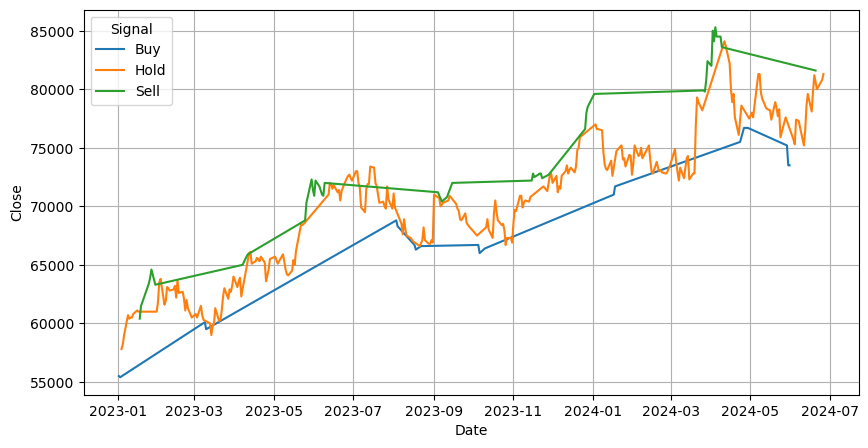

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import FinanceDataReader as fdr
import warnings

df = fdr.DataReader("005930")
df['RSI'] = calculate_rsi(df)
df = df.dropna()

# 새로운 열 'Signal' 추가하는 함수 정의
def get_signal(rsi):
    if rsi <= 30:
        return 'Buy'
    elif rsi >= 70:
        return 'Sell'
    else:
        return 'Hold'

# 데이터프레임에 새로운 열 추가
df['Signal'] = df['RSI'].apply(get_signal)

plt.figure(figsize = (10, 5))

df2 = df[df.index.year >= 2023]

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal')

plt.grid()
plt.show()

In [ ]:
stocks = fdr.StockListing("KRX")[['Code', 'Name']]
stocks

In [20]:
for i in range(len(stocks)):

    stock = stocks.iloc[i]
    code = stock['Code']
    name = stock['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['RSI'] = calculate_rsi(df)
    
    today_data = df.iloc[-1]['RSI']

    if today_data > 70:
        print(f"{name} : 매도 신호!")
    elif today_data < 30:
        print(f"{name} : 매수 신호!")

SK하이닉스 : 매도 신호!
현대차 : 매도 신호!
기아 : 매도 신호!
NAVER : 매수 신호!
현대모비스 : 매도 신호!
카카오 : 매수 신호!
LG전자 : 매도 신호!
HD현대중공업 : 매도 신호!
포스코인터내셔널 : 매도 신호!
삼성에스디에스 : 매수 신호!
HD한국조선해양 : 매도 신호!
HLB : 매도 신호!
현대글로비스 : 매도 신호!
현대차2우B : 매도 신호!
SK바이오팜 : 매수 신호!
CJ제일제당 : 매도 신호!
LG디스플레이 : 매도 신호!
LG생활건강 : 매수 신호!
한국가스공사 : 매도 신호!
넷마블 : 매수 신호!
엔켐 : 매수 신호!
LIG넥스원 : 매도 신호!
NH투자증권 : 매도 신호!
현대차우 : 매도 신호!
카카오페이 : 매수 신호!
리노공업 : 매수 신호!
현대건설 : 매수 신호!
HD현대미포 : 매도 신호!
삼성증권 : 매도 신호!
실리콘투 : 매도 신호!
강원랜드 : 매수 신호!
솔브레인 : 매수 신호!
호텔신라 : 매수 신호!
이오테크닉스 : 매수 신호!
테크윙 : 매도 신호!
에스엘 : 매도 신호!
JYP Ent. : 매수 신호!
씨에스윈드 : 매수 신호!
BGF리테일 : 매수 신호!
현대엘리베이 : 매도 신호!
OCI홀딩스 : 매수 신호!
제이앤티씨 : 매도 신호!
한샘 : 매도 신호!
피에스케이홀딩스 : 매도 신호!
이마트 : 매수 신호!
서진시스템 : 매수 신호!
ISC : 매수 신호!
한화엔진 : 매도 신호!
루닛 : 매수 신호!
LX세미콘 : 매도 신호!
종근당 : 매수 신호!
롯데손해보험 : 매도 신호!
스튜디오드래곤 : 매수 신호!
대웅제약 : 매수 신호!
하나머티리얼즈 : 매도 신호!
롯데정밀화학 : 매수 신호!
씨앤씨인터내셔널 : 매도 신호!
롯데렌탈 : 매도 신호!
동양생명 : 매도 신호!
대덕전자 : 매수 신호!
에이비엘바이오 : 매수 신호!
솔루엠 : 매수 신호!
더블유씨피 : 매수 신호!
제이시스메디칼 : 매도 신호!
대상 : 매도 신호!
덕산네오룩스 : 매수 신호!
차바이오텍 : 매수 신호

파이오링크 : 매수 신호!
마니커에프앤지 : 매도 신호!
HB인베스트먼트 : 매수 신호!
머큐리 : 매수 신호!
내츄럴엔도텍 : 매수 신호!
에스메디 : 매수 신호!
CNT85 : 매수 신호!
명문제약 : 매수 신호!
힘스 : 매수 신호!
대양금속 : 매수 신호!
에이치시티 : 매수 신호!
SH에너지화학 : 매수 신호!
엘엠에스 : 매수 신호!
대림B&Co : 매수 신호!
대호에이엘 : 매수 신호!
NE능률 : 매수 신호!
포인트모바일 : 매수 신호!
진시스템 : 매도 신호!
우리로 : 매도 신호!
에스제이그룹 : 매수 신호!
대성하이텍 : 매수 신호!
남성 : 매수 신호!
평화산업 : 매수 신호!
태양 : 매수 신호!
네오크레마 : 매수 신호!
씨이랩 : 매수 신호!
써니전자 : 매수 신호!
푸른기술 : 매수 신호!
하츠 : 매수 신호!
에스에이티 : 매도 신호!
그리티 : 매수 신호!
씨유테크 : 매수 신호!
DH오토웨어 : 매수 신호!
남광토건 : 매수 신호!
기가레인 : 매수 신호!
FSN : 매수 신호!
다스코 : 매수 신호!
고려제약 : 매수 신호!
엠젠솔루션 : 매수 신호!
산돌 : 매수 신호!
이노시뮬레이션 : 매수 신호!
부국철강 : 매수 신호!
지니너스 : 매수 신호!
삼화전자 : 매수 신호!
에이치와이티씨 : 매수 신호!
YBM넷 : 매수 신호!
모니터랩 : 매수 신호!
대원 : 매수 신호!
이스트에이드 : 매수 신호!
시디즈 : 매도 신호!
우성 : 매수 신호!
피코그램 : 매수 신호!
키네마스터 : 매수 신호!
신화인터텍 : 매수 신호!
CBI : 매수 신호!
케이피엠테크 : 매수 신호!
에이루트 : 매수 신호!
씨아이테크 : 매수 신호!
코데즈컴바인 : 매수 신호!
일진디스플 : 매수 신호!
엔피디 : 매수 신호!
재영솔루텍 : 매수 신호!
파워넷 : 매수 신호!
일신바이오 : 매수 신호!
에코캡 : 매수 신호!
얼라인드 : 매수 신호!
블루콤 : 매수 신호!
SK케미칼우 : 매수 신호!
엠아이큐브솔루션 : 매수 신호!
모아텍 : 매수

### 볼린저 밴드
볼린저 밴드(Bollinger Bands)는 1980년대에 존 볼린저(John Bollinger)에 의해 개발된 기술적 분석 도구로서, 주가의 변동성을 측정하고 상대적인 고점 또는 저점을 식별하는 데 사용됩니다. 볼린저 밴드는 가격 변동성에 따라 자동으로 넓어지거나 좁아지는 세 개의 선으로 구성되며, 이는 시장의 변동성 변화를 반영합니다.

### 볼린저 밴드의 구성
* 중심선 (Middle Band): 주식의 20일 단순 이동 평균(SMA)이 일반적으로 사용됩니다.
* 상단 밴드 (Upper Band): 중심선에서 표준 편차의 2배를 더한 값입니다.
* 하단 밴드 (Lower Band): 중심선에서 표준 편차의 2배를 뺀 값입니다.

### 볼린저 밴드의 해석
* 가격이 상단 밴드에 접근하거나 닿을 때: 시장이 과매수 상태일 수 있으며, 가격 하락의 가능성을 시사합니다.
* 가격이 하단 밴드에 접근하거나 닿을 때: 시장이 과매도 상태일 수 있으며, 가격 상승의 가능성을 시사합니다.
* 밴드의 폭: 밴드의 폭이 넓어지면(Expansion) 시장의 변동성이 높아지고 있음을 나타내고, 밴드가 좁아지면(Contraction) 시장의 변동성이 낮아지고 있음을 나타냅니다. 이는 종종 큰 가격 움직임이 발생할 수 있는 중요한 신호로 해석됩니다.

### 볼린저 밴드의 활용
* 트레이딩 범위 확인: 볼린저 밴드는 주가가 특정 범위 내에서 움직일 때 유용하게 사용될 수 있습니다. 투자자는 가격이 상단 밴드를 넘어서면 매도하고, 하단 밴드에 도달하면 매수하는 전략을 사용할 수 있습니다.
* 가격의 이탈: 가격이 볼린저 밴드의 상단 또는 하단을 강하게 돌파할 때, 이는 추세의 시작을 나타내는 강력한 신호로 간주될 수 있습니다. 이는 새로운 추세의 시작을 알리는 중요한 지표로 활용될 수 있습니다.

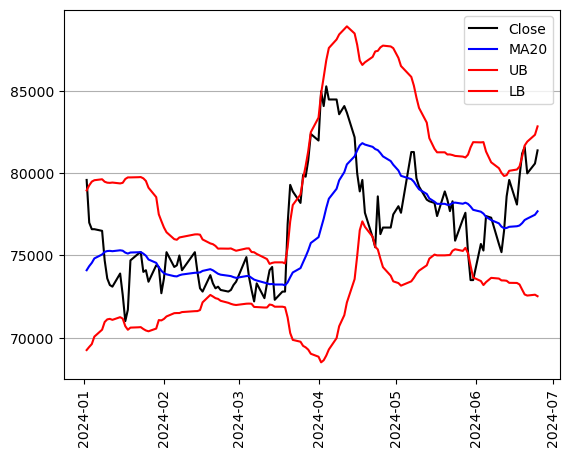

In [24]:
import pandas as pd
import numpy as np
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

df['MA20'] = df['Close'].rolling(window = 20).mean()
df['STD20'] = df['Close'].rolling(window = 20).std()

df['UB'] = df['MA20'] + 2 * df['STD20']
df['LB'] = df['MA20'] - 2 * df['STD20']

df = df[df.index.year >= 2024]

plt.plot(df['Close'],color = 'black')
plt.plot(df['MA20'], color = 'blue')
plt.plot(df['UB'], color = 'red')
plt.plot(df['LB'], color = 'red')
plt.grid(axis = 'y')
plt.legend(['Close', 'MA20', 'UB', 'LB'])
plt.xticks(rotation = 90)
plt.show()

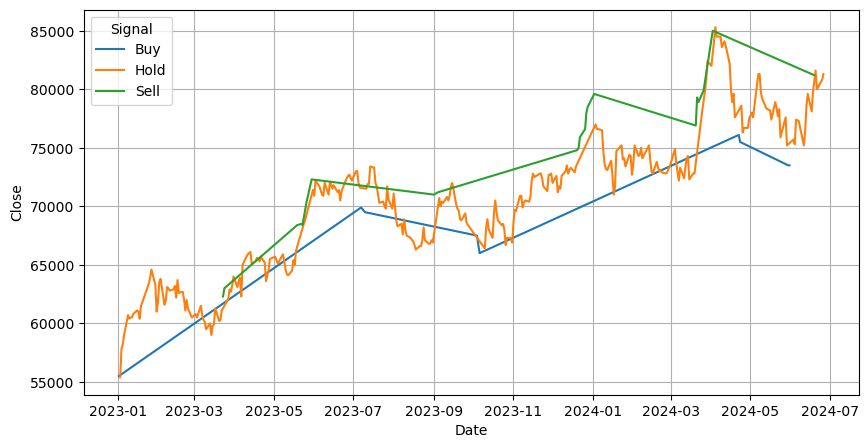

In [33]:
# 신호 생성 함수 정의
def get_bollinger_signal(row):
    if row['Close'] < row['LB']:
        return 'Buy'
    elif row['Close'] > row['UB']:
        return 'Sell'
    else:
        return 'Hold'

name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

df['MA20'] = df['Close'].rolling(window = 20).mean()
df['STD20'] = df['Close'].rolling(window = 20).std()

df['UB'] = df['MA20'] + 2 * df['STD20']
df['LB'] = df['MA20'] - 2 * df['STD20']

df2 = df[df.index.year >= 2023]

df2['Signal'] = df2.apply(get_bollinger_signal, axis=1)

plt.figure(figsize = (10, 5))

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal')

plt.grid()
plt.show()

In [27]:
stocks = fdr.StockListing("KOSPI")

for i in range(len(stocks)):

    data = stocks.iloc[i]

    code = data['Code']
    name = data['Name']

    df = fdr.DataReader(code)

    df['MA20'] = df['Close'].rolling(window = 20).mean()
    df['STD20'] = df['Close'].rolling(window = 20).std()
    
    df['UB'] = df['MA20'] + 2 * df['STD20']
    df['LB'] = df['MA20'] - 2 * df['STD20']

    today = df.iloc[-1]

    if today['Close'] < today['LB']:
        print(f"{name} 매수 신호입니다!")
    elif today['Close'] > today['UB']:
        print(f"{name} 매도 신호입니다!")

현대모비스 매도 신호입니다!
카카오 매수 신호입니다!
HD현대중공업 매도 신호입니다!
삼성에스디에스 매수 신호입니다!
우리금융지주 매도 신호입니다!
현대글로비스 매도 신호입니다!
LG디스플레이 매도 신호입니다!
HD현대 매도 신호입니다!
코웨이 매도 신호입니다!
HD현대미포 매도 신호입니다!
더존비즈온 매도 신호입니다!
한샘 매도 신호입니다!
LX세미콘 매도 신호입니다!
대덕전자 매수 신호입니다!
더블유게임즈 매도 신호입니다!
넥센타이어 매수 신호입니다!
DS단석 매도 신호입니다!
SNT모티브 매도 신호입니다!
NHN 매수 신호입니다!
보령 매수 신호입니다!
유니드 매수 신호입니다!
흥아해운 매도 신호입니다!
유진투자증권 매도 신호입니다!
쏘카 매수 신호입니다!
유안타증권 매도 신호입니다!
신세계인터내셔날 매수 신호입니다!
세진중공업 매도 신호입니다!
LX홀딩스 매도 신호입니다!
스틱인베스트먼트 매수 신호입니다!
LX하우시스 매도 신호입니다!
LF 매수 신호입니다!
남양유업 매도 신호입니다!
국도화학 매도 신호입니다!
부광약품 매수 신호입니다!
KG케미칼 매수 신호입니다!
GS글로벌 매도 신호입니다!
신성통상 매도 신호입니다!
삼양패키징 매도 신호입니다!
송원산업 매수 신호입니다!
대한제강 매수 신호입니다!
이월드 매수 신호입니다!
스카이라이프 매수 신호입니다!
일양약품 매수 신호입니다!
한국공항 매도 신호입니다!
디아이씨 매도 신호입니다!
남선알미늄 매수 신호입니다!
KSS해운 매도 신호입니다!
TYM 매수 신호입니다!
S-Oil우 매수 신호입니다!
진원생명과학 매수 신호입니다!
태경산업 매수 신호입니다!
대창단조 매수 신호입니다!
아주스틸 매수 신호입니다!
삼양통상 매수 신호입니다!
한컴라이프케어 매수 신호입니다!
에스엠벡셀 매수 신호입니다!
벽산 매도 신호입니다!
삼성공조 매도 신호입니다!
신원 매도 신호입니다!
동성제약 매수 신호입니다!
대영포장 매수 신호입니다!
성창기업지주 매수 신호입니다!
와이투솔루션 매수 신호입니다!
종근당바이오 매수 신호입니다!

## 포트폴리오 이론
포트폴리오 이론은 투자 포트폴리오를 구성하고 관리하는 방법에 관한 경제학적 이론으로, 투자 위험을 최소화하고 기대 수익을 최대화하는 방법을 모색합니다. 이 이론은 1952년 해리 마코위츠(Harry Markowitz)에 의해 "포트폴리오 선택(Portfolio Selection)" 논문에서 처음 제시되었으며, 이는 현대 포트폴리오 이론(Modern Portfolio Theory, MPT)의 기초가 되었습니다.

### 포트폴리오 이론의 주요 개념
* 분산 투자: 투자 리스크를 줄이기 위해 여러 자산에 걸쳐 투자함으로써 한 자산의 부진이 전체 포트폴리오에 미치는 영향을 최소화합니다.

* 효율적 투자선(Efficient Frontier): 주어진 위험 수준에서 최대의 기대 수익을 제공하는 자산 조합을 나타내는 곡선입니다. 이 곡선 위의 포트폴리오는 주어진 위험에 대해 최대의 수익을 제공하므로 '효율적'이라고 합니다.

* 기대 수익률과 위험: 포트폴리오의 기대 수익률은 포함된 각 자산의 기대 수익률과 그 비중에 따라 계산되며, 위험(변동성)은 자산 간 상관관계에 따라 다르게 나타납니다. 낮은 상관관계의 자산 조합은 포트폴리오의 전체 위험을 줄일 수 있습니다.

* 시장 포트폴리오: 모든 투자 가능 자산을 포함하며, 모든 효율적 포트폴리오는 이 시장 포트폴리오와 무위험 자산의 조합으로 표현될 수 있습니다.

### 포트폴리오 이론의 중요성
포트폴리오 이론은 개별 투자보다는 전체 포트폴리오의 성과에 초점을 맞춥니다. 이 이론은 투자자가 자신의 위험 선호도에 맞는 자산 조합을 선택할 수 있도록 도와주며, 다음과 같은 중요한 이점을 제공합니다.

* 위험 관리: 서로 다른 자산 간의 상관관계를 고려하여 위험을 분산시키고, 전체적인 포트폴리오의 변동성을 줄입니다.
* 투자 결정 지원: 투자자는 자신의 위험 감수 능력과 기대 수익률에 기반하여 합리적인 투자 결정을 내릴 수 있습니다.
* 자산 할당: 자산 간의 비중을 조절함으로써 기대 수익을 최적화하고, 경제적 환경 변화에 따라 포트폴리오를 조정할 수 있습니다.

포트폴리오 이론은 투자자에게 체계적이고 과학적인 접근 방식을 제공하여, 감정에 휘둘리지 않고 투자 결정을 내릴 수 있는 토대를 마련해 줍니다. 이 이론을 통해 투자자는 경제적 환경의 변화에도 견딜 수 있는 견고한 투자 전략을 수립할 수 있습니다.

In [26]:
import numpy as np

# 수익률 데이터
returns = np.array([0.05, 0.07, -0.02, 0.10, 0.04])

# 평균 수익률 계산
mean_return = np.mean(returns)

# 각 수익률에서 평균을 뺀 값을 제곱한 후 평균을 계산
variance = np.mean((returns - mean_return) ** 2)

# 표준편차 계산
std_dev = np.sqrt(variance)
std_dev

0.03969886648255842

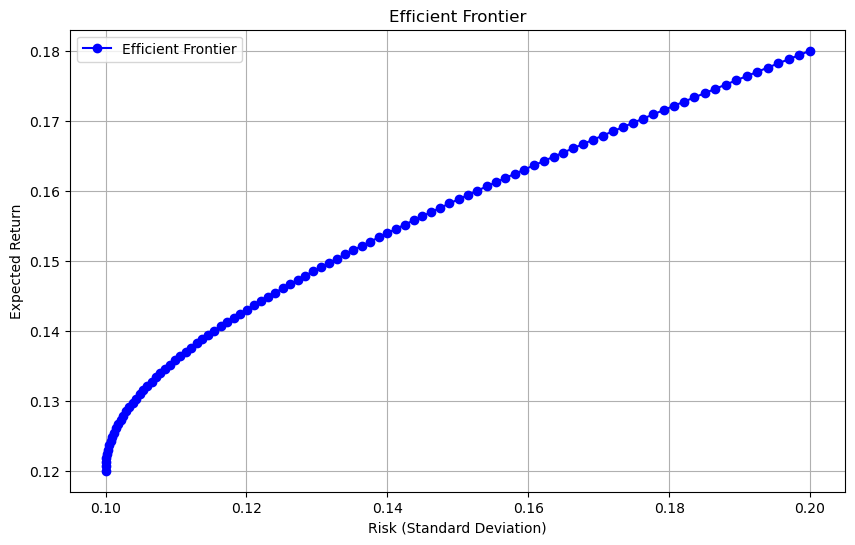

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 예시 자산의 수익률과 표준편차 (리스크)
returns = np.array([0.12, 0.18])  # 자산의 기대 수익률
risks = np.array([0.1, 0.2])      # 자산의 표준편차 (리스크)
correlation = 0.5                 # 두 자산의 상관관계

# 공분산 행렬 계산
cov_matrix = np.array([[risks[0]**2, risks[0]*risks[1]*correlation],
                       [risks[0]*risks[1]*correlation, risks[1]**2]])

# 포트폴리오 수익률과 리스크 계산
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.sum(weights * returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_risk

# 다양한 포트폴리오의 수익률과 리스크 계산
weights_list = []
portfolio_returns = []
portfolio_risks = []

for w1 in np.linspace(0, 1, 100):
    w2 = 1 - w1
    weights = np.array([w1, w2])
    ret, risk = portfolio_performance(weights, returns, cov_matrix)
    weights_list.append(weights)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

# 효율적 투자선 그리기
plt.figure(figsize=(10, 6))
plt.plot(portfolio_risks, portfolio_returns, 'b-o', label='Efficient Frontier')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
import FinanceDataReader as fdr

stocks = fdr.DataReader(['AAPL', 'TSLA', 'META'])
stocks = stocks.dropna()
stocks

,AAPL,TSLA,META
Date,,,
2012-05-18,16.014687,1.837333,38.230000
2012-05-21,16.947701,1.918000,34.029999
2012-05-22,16.817558,2.053333,31.000000
2012-05-23,17.227909,2.068000,32.000000
2012-05-24,17.069687,2.018667,33.029999
...,...,...,...
2024-06-17,216.669998,187.440002,506.630005
2024-06-18,214.289993,184.860001,499.489990
2024-06-20,209.679993,181.570007,501.700012


In [30]:
daily_ret = stocks.pct_change()
annual_ret = stocks.mean()

daily_cov = daily_ret.cov()
annual_cov = daily_cov * 252

port_ret = []
port_risk = []
port_weights = []

In [31]:
import pandas as pd

for i in range(100000):

    weights = np.random.random(3)
    weights /= np.sum(weights)

    returns = np.dot(weights, annual_ret)
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))

    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)

portfolio = {'Returns' : port_ret, "Risk" : port_risk}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk'] + [s for s in stocks.columns]]
df

,Returns,Risk,AAPL,TSLA,META
0,90.189309,0.306570,0.529138,0.331558,0.139304
1,86.860825,0.356525,0.419774,0.498367,0.081859
2,126.927760,0.370610,0.053859,0.447412,0.498729
3,132.428847,0.328828,0.177660,0.237966,0.584373
4,118.981181,0.322761,0.248592,0.315417,0.435991
...,...,...,...,...,...
99995,81.494800,0.358343,0.472426,0.500949,0.026625
99996,100.703738,0.340755,0.327494,0.441048,0.231459
99997,82.241534,0.415288,0.331700,0.655764,0.012536
99998,81.542286,0.320676,0.576729,0.379056,0.044215


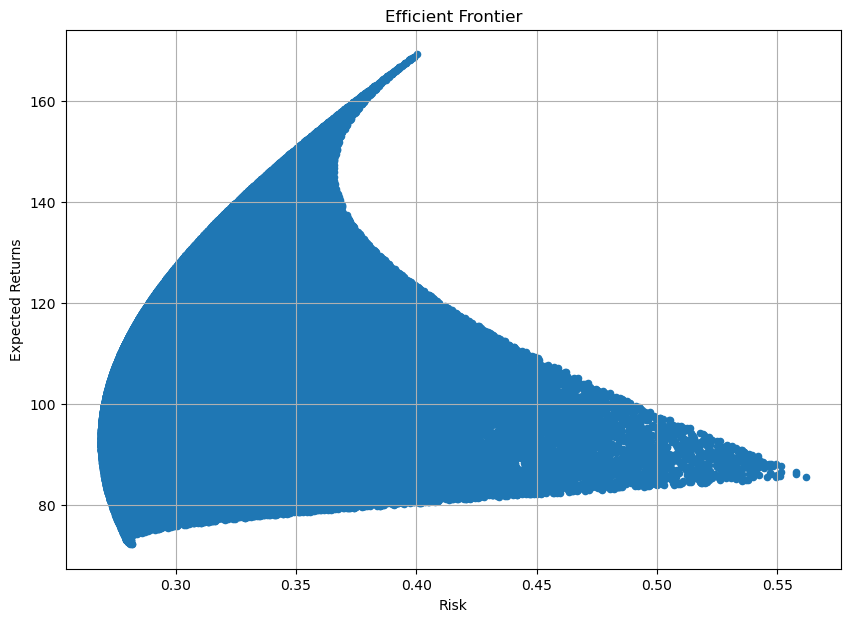

In [32]:
import matplotlib.pyplot as plt

df.plot.scatter(x = 'Risk', y = 'Returns', figsize = (10, 7), grid = True)

plt.title("Efficient Frontier")
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()

In [33]:
daily_ret = stocks.pct_change()
annual_ret = stocks.mean()

daily_cov = daily_ret.cov()
annual_cov = daily_cov * 252

port_ret = []
port_risk = []
port_weights = []
sharpe_ratio = []

for i in range(100000):

    weights = np.random.random(3)
    weights /= np.sum(weights)

    returns = np.dot(weights, annual_ret)
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))

    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)
    sharpe_ratio.append(returns / risk)

portfolio = {'Returns' : port_ret, "Risk" : port_risk, 'Sharpe' : sharpe_ratio}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk', 'Sharpe'] + [s for s in stocks.columns]]

max_sharpe = df.loc[df['Sharpe'] == df['Sharpe'].max()]
max_sharpe

,Returns,Risk,Sharpe,AAPL,TSLA,META
3003,144.454042,0.335532,430.522002,0.240047,0.022356,0.737598


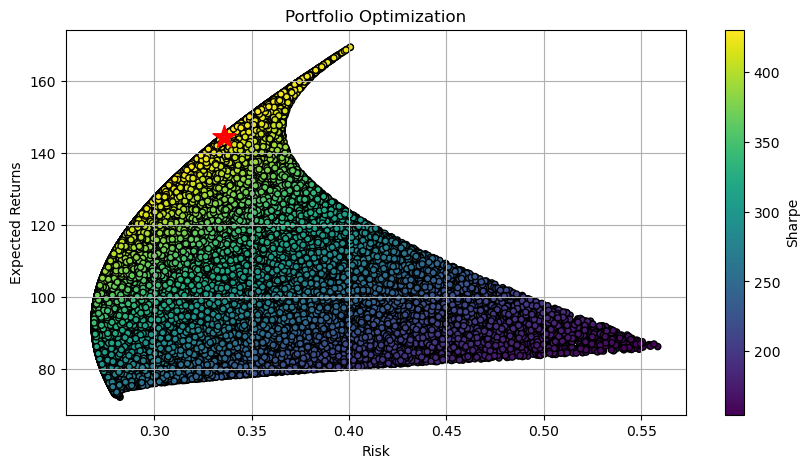

In [34]:
df.plot.scatter(x = 'Risk', y = 'Returns', c = 'Sharpe', cmap = 'viridis', edgecolors = 'k', figsize = (10, 5), grid = True)
plt.scatter(x = max_sharpe['Risk'], y = max_sharpe['Returns'], c = 'r', marker = '*', s = 300)
plt.title('Portfolio Optimization')
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()

## 인공지능 주가 예측
인공지능(AI)을 이용한 주가 예측은 기계 학습 및 딥러닝 기술을 활용하여 주식 시장의 미래 가격을 예측하는 방법입니다. 이러한 접근 방식은 엄청난 양의 과거 및 현재 데이터를 분석하여 주가의 패턴을 식별하고, 이를 바탕으로 미래의 주가 움직임을 예측합니다.

### 인공지능 주가 예측의 핵심 구성 요소
* 데이터 수집: 주가 예측을 위해 과거 주가, 거래량, 금융 뉴스, 경제 지표, 기업 실적 보고서 등 다양한 데이터를 수집합니다.

* 특성 추출 및 처리: 수집된 데이터에서 유용한 정보를 추출하고, 누락된 값 처리, 정규화, 변수 변환 등의 데이터 전처리 과정을 거칩니다.

* 모델 선택과 학습: 여러 종류의 기계 학습 알고리즘(선형 회귀, 결정 트리, 랜덤 포레스트, 인공 신경망 등) 중 하나를 선택하여 훈련 데이터를 기반으로 모델을 학습시킵니다.

* 검증 및 테스트: 검증 데이터셋을 사용하여 모델의 성능을 평가하고, 테스트 데이터셋을 통해 모델의 일반화 능력을 확인합니다.

* 실시간 예측 및 조정: 모델을 실제 주가 예측에 적용하고, 시장 변화나 추가 데이터를 반영하여 모델을 지속적으로 조정합니다.

### 인공지능 주가 예측의 사례
인공지능 주가 예측은 여러 금융 기관과 투자 회사에서 활용되고 있습니다. 예를 들어, 퀀트 헤지펀드와 알고리즘 트레이딩 회사들은 복잡한 수학적 모델과 AI 기술을 사용하여 주가의 미세한 변동을 포착하고, 이를 기반으로 빠르게 매매를 진행함으로써 이익을 창출하고 있습니다. 이와 같은 방식은 전통적인 투자 분석 방법보다 훨씬 빠르고 효율적일 수 있지만, 높은 위험도 동반될 수 있음을 인지해야 합니다.

### 데이터 수집하고 문제집 & 정답지 만들기

In [ ]:
import FinanceDataReader as fdr
import numpy as np

df = fdr.DataReader("005930").dropna() # 주가 데이터를 수집

x = []
y = []

for i in range(len(df) - 1):    # i 의 값은 마지막 행을 제외
    
    a = df.iloc[i].to_numpy()   # 당일 주식 정보 ==> 문제집
    b = df.iloc[i+1]['Close']   # 익일 주식 종가 ==> 정답지
    
    x.append(a)
    y.append(b)
    
# for 문으로 정리한 x,y 를 numpy 배열로 전환
x = np.array(x)     
y = np.array(y)

### K 최근접 이웃 모델을 활용한 다음날 주식 가격 예측
K-최근접 이웃(K-Nearest Neighbors, KNN) 모델은 분류와 회귀 분석에 모두 사용할 수 있는 단순하고 직관적인 기계 학습 알고리즘입니다. KNN은 새로운 데이터 포인트의 클래스나 값을 예측할 때, 훈련 데이터에서 가장 가까운 K개의 이웃을 참고하여 결정을 내립니다. 이 알고리즘은 주로 패턴 인식, 데이터 마이닝, 통계 분석 등 다양한 분야에서 사용됩니다.

In [ ]:
# k 분류 모델 적용 : 가장 가까운 값들의 갯수
# k 회귀 모델 적용 : 가장 가까운 값들의 평균

# KNN 최근접 회귀 모델 가져오기
from sklearn.neighbors import KNeighborsRegressor
# 데이터를 학습/테스트 세트로 나눠주는 함수 가져오기
from sklearn.model_selection import train_test_split

# 학습/테스트 데이터 만들기 위한 주식 데이터 가져오는 라이브러리
import FinanceDataReader as fdr
# 데이터 처리를 위한 라이브러리 :: pandas
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)

# 데이터 분할
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 생성, 학습 ==> train data 를 사용
model = KNeighborsRegressor()   
model.fit(train_x, train_y)

# 모델 평가 ==> test data 를 사용
# ***** 테스트 데이터를 사용하여 모델의 성능을 평가하고, 결정 계수를 score 에 저장
score = model.score(test_x, test_y)

# 예측 위한 df 데이터 프레임 마지막 행 데이터를 numpy 배열로 변환
today_data = df.iloc[-1].to_numpy()

# 모델 예측 
pred = model.predict([today_data])[0]

# 예측된 pred 를 포매팅하여 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

### 결정트리 모델을 활용한 다음날 주식 가격 예측
결정 트리(Decision Tree) 모델은 분류와 회귀 분석에 모두 사용할 수 있는 비모수적 기계 학습 알고리즘입니다. 결정 트리는 데이터의 특성과 대상 값을 기준으로 데이터를 분할하여 의사 결정 규칙을 학습하는 방법입니다. 트리 구조는 루트 노드, 내부 노드, 리프 노드로 구성되며, 각 내부 노드는 데이터의 특성을 기준으로 분할하고, 리프 노드는 최종 예측 결과를 나타냅니다.
가지치기 pruning 로 overfitting 보완, 앙상블 기법 random forest 로 안정성을 확보할 수 있다 

In [ ]:
# 트리의 결정트리 모델 import 
from sklearn.tree import DecisionTreeRegressor
# data 분함 함수 
from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 학습
model = DecisionTreeRegressor()
model.fit(train_x, train_y)     # fitting 한다. over/under...
# 모델 평가
score = model.score(test_x, test_y)
# 예측일 데이터 생성
today_data = df.iloc[-1].to_numpy()
# 모델 예측
pred = model.predict([today_data])[0]
# 결과 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2024-06-26의 삼성전자의 주식 예측 가격은 81,200원입니다. 오차 범위는 0.16% 입니다.


### 랜덤포레스트 모델을 활용한 다음날 주식 가격 예측
랜덤 포레스트(Random Forest) 모델은 다수의 결정 트리를 사용하여 분류나 회귀 작업을 수행하는 앙상블 학습 방법 중 하나입니다. 이는 개별 결정 트리의 약점을 보완하고, 모델의 성능과 안정성을 향상시키기 위해 개발되었습니다. 랜덤 포레스트는 배깅(Bagging) 기법과 특성 무작위성(feature randomness)을 결합하여 다수의 결정 트리를 생성하고, 이들의 예측을 결합하여 최종 결과를 도출합니다.

* 부트 스트랩 샘플링
    원본 데이터에서 중복을 허용하여 여러 개의 샘플 데이터를 생성
* 랜덤 피처 선택
    각 [루프, 인터널, 리프 노드 ... ???] 를 분할할때 전체 피처 (what ?) 중 무작위로 선택된 일부 피처만을 고려
* 결정 트리 : 부트 스트랩과 랜덤 피처를 사용하여 다수의 결정 트리를 생성
* 앙상블 예측 :
    분류 문제 - 각 트리의 예측 결과를 투표하여 가장 많이 선택된 클래스가 최종 예측
    회귀 문제 - 각 트리의 예측 결과를 평균한 것이 최종 예측

In [ ]:
# 앙상블의 랜덤포레스트 모델 임포트
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 초기화
model = RandomForestRegressor()
# 모델 헉숩
model.fit(train_x, train_y)
# 모델 평가  ==> 모델 라이브러리 에서 알아서 스코어 생성 ???
score = model.score(test_x, test_y)

# 예측
today_data = df.iloc[-1].to_numpy()
pred = model.predict([today_data])[0]

# 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2024-06-26의 삼성전자의 주식 예측 가격은 81,042원입니다. 오차 범위는 0.07% 입니다.


### XGBoost 모델을 활용한 다음날 주식 가격 예측
XGBoost(Extreme Gradient Boosting) 모델은 결정 트리 알고리즘을 기반으로 한 강력한 앙상블 학습 기법입니다. 이는 주로 분류와 회귀 분석에 사용되며, 높은 예측 성능과 효율성 덕분에 다양한 데이터 과학 대회에서 널리 사용됩니다. XGBoost는 그레디언트 부스팅(Gradient Boosting) 알고리즘의 확장판으로, 성능을 최적화하고 실행 속도를 높이기 위해 여러 가지 개선 사항을 도입했습니다.

In [ ]:
# Decision Tree : 여러개의 결정 트리를 사용하여 각각 약한 학습자로 작동하며 이들이 모여 강력한 예측 모델을 형성 
# 오차 Residuals : 현재 모델의 예측과 실젯값 사이 차이를 계산하여 새로운 트리를 학습
# 학습율 Learning Rate : 각 트리의 기여도를 조절하여 모델이 천천히 학습되도록 한다.
# 규제 Regulations : L1, L2 규제, 모델의 복잡성을 제어하여 오버피팅 방지
# Boosting Stage : 여러 트리를 순차적으로 추가하여 모델 성능을 점진적으로 향상

# xgboost 에서 xgbregressor 를 import
# 결정 트리 모델을 업그레이드한 모델
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 초기화
model = XGBRegressor()
# 학습
model.fit(train_x, train_y)
# 평가
score = model.score(test_x, test_y)

# 예측/추론 ??
today_data = df.iloc[-1].to_numpy()
pred = model.predict([today_data])[0]

# 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2024-06-26의 삼성전자의 주식 예측 가격은 81,973원입니다. 오차 범위는 0.09% 입니다.


### 국내 주식 미래 주식 가격 예측하기
랜덤 포레스트 모델을 사용해서 우리나라 국내 모든 주식 종목의 다음날 가격을 예측하는 프로그램을 만들어보겠습니다.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

# 상장 주식 목록을 가져오기
stocks = fdr.StockListing("KRX")

for s in range(len(stocks)):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    # 종목 코드를 사용하여 주식 데이터를 가져오고, 결측값을 제거 
    # 아... naver 주식 자료를 가져오는 것이라서 코드에 naver 를 붙여서 코드 값 생성 ???
    df = fdr.DataReader("NAVER:" + code).dropna()
    
    x = []
    y = []

    for i in range(len(df) - 1):

        a = df.iloc[i].to_numpy()
        b = df.iloc[i+1]['Close']

        x.append(a)
        y.append(b)

    train_x, test_x, train_y, test_y = train_test_split(x, y)

    # 모델 초기화
    model = RandomForestRegressor()
    # fitting == 학습
    model.fit(train_x, train_y)
    # 평가
    score = model.score(test_x, test_y)

    # 예측 
    today_data = df.iloc[-1].to_numpy()
    pred = model.predict([today_data])[0]

    # 출력
    date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]

    #today_price = int(df.iloc[-1]['Close'])
    #if today_price < pred:
    #    print(f"[{date}] {name} 추천! 현재 가격 {today_price:,}원 --> 예측 가격 {int(pred):,}원(오차 범위 {(1-score) * 100:.2f}%)")

    print(f"{date}의 {name}의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2024-06-26의 삼성전자의 주식 예측 가격은 81,986원입니다. 오차 범위는 0.09% 입니다.
2024-06-26의 SK하이닉스의 주식 예측 가격은 223,555원입니다. 오차 범위는 0.40% 입니다.
2024-06-26의 LG에너지솔루션의 주식 예측 가격은 334,350원입니다. 오차 범위는 2.54% 입니다.
2024-06-26의 현대차의 주식 예측 가격은 284,275원입니다. 오차 범위는 0.24% 입니다.
2024-06-26의 삼성전자우의 주식 예측 가격은 64,266원입니다. 오차 범위는 0.06% 입니다.
2024-06-26의 삼성바이오로직스의 주식 예측 가격은 738,023원입니다. 오차 범위는 0.41% 입니다.
2024-06-26의 기아의 주식 예측 가격은 128,841원입니다. 오차 범위는 0.15% 입니다.
2024-06-26의 셀트리온의 주식 예측 가격은 178,634원입니다. 오차 범위는 0.23% 입니다.
2024-06-26의 KB금융의 주식 예측 가격은 78,995원입니다. 오차 범위는 1.04% 입니다.
2024-06-26의 POSCO홀딩스의 주식 예측 가격은 367,840원입니다. 오차 범위는 0.39% 입니다.
2024-06-26의 NAVER의 주식 예측 가격은 166,334원입니다. 오차 범위는 0.15% 입니다.
2024-06-26의 삼성SDI의 주식 예측 가격은 367,395원입니다. 오차 범위는 0.15% 입니다.
2024-06-26의 LG화학의 주식 예측 가격은 348,655원입니다. 오차 범위는 0.22% 입니다.
2024-06-26의 신한지주의 주식 예측 가격은 47,973원입니다. 오차 범위는 0.51% 입니다.
2024-06-26의 삼성물산의 주식 예측 가격은 136,302원입니다. 오차 범위는 2.67% 입니다.
2024-06-26의 현대모비스의 주식 예측 가격은 252,660원입니다. 오차 범위는 0.18% 입니다.
2024-06-26의 포스코퓨처엠의 주식 예측 가격은 258,920원입니다. 오차

2024-06-26의 한화생명의 주식 예측 가격은 2,955원입니다. 오차 범위는 0.23% 입니다.
2024-06-26의 휠라홀딩스의 주식 예측 가격은 40,396원입니다. 오차 범위는 0.32% 입니다.
2024-06-26의 롯데에너지머티리얼즈의 주식 예측 가격은 53,638원입니다. 오차 범위는 0.34% 입니다.
2024-06-26의 F&F의 주식 예측 가격은 62,700원입니다. 오차 범위는 1.27% 입니다.
2024-06-26의 DB하이텍의 주식 예측 가격은 50,532원입니다. 오차 범위는 0.27% 입니다.
2024-06-26의 솔브레인의 주식 예측 가격은 292,967원입니다. 오차 범위는 3.57% 입니다.
2024-06-26의 GS리테일의 주식 예측 가격은 21,763원입니다. 오차 범위는 0.77% 입니다.
2024-06-26의 대주전자재료의 주식 예측 가격은 145,768원입니다. 오차 범위는 0.26% 입니다.
2024-06-26의 팬오션의 주식 예측 가격은 4,117원입니다. 오차 범위는 0.42% 입니다.
2024-06-26의 CJ대한통운의 주식 예측 가격은 97,061원입니다. 오차 범위는 0.17% 입니다.
2024-06-26의 에스원의 주식 예측 가격은 57,539원입니다. 오차 범위는 0.23% 입니다.
2024-06-26의 더존비즈온의 주식 예측 가격은 67,446원입니다. 오차 범위는 0.27% 입니다.
2024-06-26의 한미사이언스의 주식 예측 가격은 31,989원입니다. 오차 범위는 0.38% 입니다.
2024-06-26의 호텔신라의 주식 예측 가격은 54,190원입니다. 오차 범위는 0.19% 입니다.
2024-06-26의 제일기획의 주식 예측 가격은 18,509원입니다. 오차 범위는 0.25% 입니다.
2024-06-26의 이오테크닉스의 주식 예측 가격은 176,665원입니다. 오차 범위는 0.27% 입니다.
2024-06-26의 HL만도의 주식 예측 가격은 45,915원입니다. 오차 범위는 1.00% 입니다

2024-06-26의 빙그레의 주식 예측 가격은 104,271원입니다. 오차 범위는 0.22% 입니다.
2024-06-26의 카페24의 주식 예측 가격은 42,238원입니다. 오차 범위는 0.71% 입니다.
2024-06-26의 하나투어의 주식 예측 가격은 60,547원입니다. 오차 범위는 0.31% 입니다.
2024-06-26의 피에스케이의 주식 예측 가격은 33,421원입니다. 오차 범위는 1.33% 입니다.
2024-06-26의 넥슨게임즈의 주식 예측 가격은 14,880원입니다. 오차 범위는 2.34% 입니다.
2024-06-26의 대상의 주식 예측 가격은 27,904원입니다. 오차 범위는 0.25% 입니다.
2024-06-26의 오리온홀딩스의 주식 예측 가격은 15,304원입니다. 오차 범위는 0.15% 입니다.
2024-06-26의 원익QnC의 주식 예측 가격은 35,906원입니다. 오차 범위는 0.17% 입니다.
2024-06-26의 덕산네오룩스의 주식 예측 가격은 37,991원입니다. 오차 범위는 0.48% 입니다.
2024-06-26의 LS에코에너지의 주식 예측 가격은 30,541원입니다. 오차 범위는 1.82% 입니다.
2024-06-26의 에코프로에이치엔의 주식 예측 가격은 62,422원입니다. 오차 범위는 5.42% 입니다.
2024-06-26의 미원상사의 주식 예측 가격은 198,819원입니다. 오차 범위는 0.04% 입니다.
2024-06-26의 한일시멘트의 주식 예측 가격은 13,648원입니다. 오차 범위는 1.59% 입니다.
2024-06-26의 성일하이텍의 주식 예측 가격은 77,480원입니다. 오차 범위는 2.21% 입니다.
2024-06-26의 대웅의 주식 예측 가격은 15,703원입니다. 오차 범위는 0.43% 입니다.
2024-06-26의 대한유화의 주식 예측 가격은 140,359원입니다. 오차 범위는 0.23% 입니다.
2024-06-26의 케이씨텍의 주식 예측 가격은 42,964원입니다. 오차 범위는 2.03% 입니다.


2024-06-26의 티웨이항공의 주식 예측 가격은 2,681원입니다. 오차 범위는 1.00% 입니다.
2024-06-26의 유진투자증권의 주식 예측 가격은 5,881원입니다. 오차 범위는 0.59% 입니다.
2024-06-26의 퍼시스의 주식 예측 가격은 49,994원입니다. 오차 범위는 0.56% 입니다.
2024-06-26의 고려제강의 주식 예측 가격은 22,630원입니다. 오차 범위는 0.35% 입니다.
2024-06-26의 아이티엠반도체의 주식 예측 가격은 24,403원입니다. 오차 범위는 1.01% 입니다.
2024-06-26의 지역난방공사의 주식 예측 가격은 48,952원입니다. 오차 범위는 0.39% 입니다.
2024-06-26의 윤성에프앤씨의 주식 예측 가격은 70,709원입니다. 오차 범위는 1.38% 입니다.
2024-06-26의 애경산업의 주식 예측 가격은 21,389원입니다. 오차 범위는 0.60% 입니다.
2024-06-26의 웹젠의 주식 예측 가격은 16,175원입니다. 오차 범위는 0.82% 입니다.
2024-06-26의 동아에스티의 주식 예측 가격은 63,182원입니다. 오차 범위는 1.14% 입니다.
2024-06-26의 풀무원의 주식 예측 가격은 14,865원입니다. 오차 범위는 0.24% 입니다.
2024-06-26의 교보증권의 주식 예측 가격은 4,900원입니다. 오차 범위는 0.63% 입니다.
2024-06-26의 콜마비앤에이치의 주식 예측 가격은 18,846원입니다. 오차 범위는 0.76% 입니다.
2024-06-26의 한국카본의 주식 예측 가격은 10,745원입니다. 오차 범위는 0.43% 입니다.
2024-06-26의 펌텍코리아의 주식 예측 가격은 45,254원입니다. 오차 범위는 1.90% 입니다.
2024-06-26의 세진중공업의 주식 예측 가격은 9,019원입니다. 오차 범위는 0.75% 입니다.
2024-06-26의 자화전자의 주식 예측 가격은 24,811원입니다. 오차 범위는 0.58% 입니다.
2024-0

2024-06-26의 신도리코의 주식 예측 가격은 37,802원입니다. 오차 범위는 0.52% 입니다.
2024-06-26의 락앤락의 주식 예측 가격은 8,759원입니다. 오차 범위는 0.41% 입니다.
2024-06-26의 젬백스링크의 주식 예측 가격은 2,937원입니다. 오차 범위는 0.45% 입니다.
2024-06-26의 바디텍메드의 주식 예측 가격은 16,316원입니다. 오차 범위는 0.86% 입니다.
2024-06-26의 한양디지텍의 주식 예측 가격은 23,896원입니다. 오차 범위는 0.47% 입니다.
2024-06-26의 월덱스의 주식 예측 가격은 22,613원입니다. 오차 범위는 0.20% 입니다.
2024-06-26의 삼천리의 주식 예측 가격은 92,412원입니다. 오차 범위는 0.20% 입니다.
2024-06-26의 휴온스의 주식 예측 가격은 31,077원입니다. 오차 범위는 1.69% 입니다.
2024-06-26의 한국자산신탁의 주식 예측 가격은 3,005원입니다. 오차 범위는 0.44% 입니다.
2024-06-26의 토비스의 주식 예측 가격은 22,622원입니다. 오차 범위는 0.47% 입니다.
2024-06-26의 에이디테크놀로지의 주식 예측 가격은 27,440원입니다. 오차 범위는 0.88% 입니다.
2024-06-26의 국도화학의 주식 예측 가격은 40,825원입니다. 오차 범위는 0.34% 입니다.
2024-06-26의 콜마홀딩스의 주식 예측 가격은 10,042원입니다. 오차 범위는 0.20% 입니다.
2024-06-26의 KG에코솔루션의 주식 예측 가격은 7,468원입니다. 오차 범위는 0.93% 입니다.
2024-06-26의 CJ4우(전환)의 주식 예측 가격은 86,396원입니다. 오차 범위는 2.50% 입니다.
2024-06-26의 하이비젼시스템의 주식 예측 가격은 24,907원입니다. 오차 범위는 0.81% 입니다.
2024-06-26의 한국비엔씨의 주식 예측 가격은 5,451원입니다. 오차 범위는 2.13% 입니다.
202

2024-06-26의 CR홀딩스의 주식 예측 가격은 6,111원입니다. 오차 범위는 0.63% 입니다.
2024-06-26의 JTC의 주식 예측 가격은 5,535원입니다. 오차 범위는 0.82% 입니다.
2024-06-26의 알루코의 주식 예측 가격은 2,922원입니다. 오차 범위는 0.29% 입니다.
2024-06-26의 뷰웍스의 주식 예측 가격은 28,202원입니다. 오차 범위는 0.39% 입니다.
2024-06-26의 코세스의 주식 예측 가격은 17,501원입니다. 오차 범위는 0.47% 입니다.
2024-06-26의 지누스의 주식 예측 가격은 13,631원입니다. 오차 범위는 0.56% 입니다.
2024-06-26의 HJ중공업의 주식 예측 가격은 3,362원입니다. 오차 범위는 0.26% 입니다.
2024-06-26의 뉴파워프라즈마의 주식 예측 가격은 6,321원입니다. 오차 범위는 1.71% 입니다.
2024-06-26의 포스코스틸리온의 주식 예측 가격은 46,615원입니다. 오차 범위는 0.97% 입니다.
2024-06-26의 디앤디파마텍의 주식 예측 가격은 27,960원입니다. 오차 범위는 17.65% 입니다.
2024-06-26의 듀켐바이오의 주식 예측 가격은 10,343원입니다. 오차 범위는 1.97% 입니다.
2024-06-26의 DB의 주식 예측 가격은 1,397원입니다. 오차 범위는 0.70% 입니다.
2024-06-26의 유진기업의 주식 예측 가격은 3,634원입니다. 오차 범위는 0.81% 입니다.
2024-06-26의 대한제당의 주식 예측 가격은 3,111원입니다. 오차 범위는 0.48% 입니다.
2024-06-26의 제테마의 주식 예측 가격은 15,793원입니다. 오차 범위는 1.60% 입니다.
2024-06-26의 인텍플러스의 주식 예측 가격은 21,580원입니다. 오차 범위는 0.38% 입니다.
2024-06-26의 삼진제약의 주식 예측 가격은 19,866원입니다. 오차 범위는 0.28% 입니다.
2024-06-26의 제일엠앤에

ValueError: With n_samples=0, test_size=0.25 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## 하루 5% 이상 급등하는 종목 찾기
사실 주식 가격 예측에서 회귀 모델을 사용하는 것은 좋은 방법이 아닐 수 있습니다. 이는 머신러닝 모델의 특성 때문입니다. 머신러닝 모델은 낮은 오차율을 목표로 학습합니다. 이 과정에서 모델은 전날 주식 가격을 기준으로 다음 날의 가격을 예측하려 할 것입니다. 이는 전날 가격과 다음 날 가격이 크게 다르지 않을 가능성이 높기 때문입니다.
따라서 미래 주식 가격을 예측할 때는 회귀 모델보다는 분류 모델을 사용하는 것이 더 적합할 수 있습니다. 이번에는 하루에 5% 이상 급등하는 종목을 찾기 위해, 5% 이상 급등하면 1, 그렇지 않으면 0으로 정답지를 분류하여 머신러닝 모델을 만들고 학습해보겠습니다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 분류 모델의 성능 평가를 위한 보고서를 생성하는 함수
from sklearn.metrics import classification_report

import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    
    # 1.03 3% 보다 큰 지를 확인
    b = int(df.iloc[i]['Close'] * 1.03 <= df.iloc[i+1]['Close'])
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 위에서 생성하여 분할 정리한 train, test data 활용
# 모델 초기화
model = RandomForestClassifier()
# 학습
model.fit(train_x, train_y)

report = classification_report(test_y, model.predict(test_x))
print(report)

# 추가 되는 코드 ==> 그런데 아래 쪽에 코드 또 있음
# 랜덤 포레스트 모델을 사용하여 내일 삼성전자 주식이 오를지 떨어질지를 예측해 본다

# today_data = df.iloc[-1].to_numpy
# date = str(df.iloc[-1].name + pd.Timedelta(days-1)).split()[0]
# pred = model.predict([today_data])[0]

# if pred:
#     print(f"{date} 기준 삼성전자 주식은 내일 5% 이상 급등합니다.")
# else:    
#     print(f"{date} 기준 삼성전자 주식은 내일 5% 이상 급등하지 않습니다.")

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1385
           1       0.60      0.03      0.05       115

    accuracy                           0.92      1500
   macro avg       0.76      0.51      0.51      1500
weighted avg       0.90      0.92      0.89      1500



In [38]:
today_data = df.iloc[-1].to_numpy()
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]

pred = model.predict([today_data])[0]

if pred:
    print(f"{date}기준 삼성전자 주식은 내일 5% 이상 급등합니다.")
else:
    print(f"{date}기준 삼성전자 주식은 내일 5% 이상 급등하지 못할 것입니다.")

2024-06-27기준 삼성전자 주식은 내일 5% 이상 급등하지 못할 것입니다.


### 모델 성능 높이기
하루에 5% 이상 급등하는 주식을 잘 찾지 못하는 이유는 여러 가지가 있을 수 있습니다. 머신러닝 모델이 참고한 특성은 시가, 고가, 저가, 종가, 거래량, 변화율로 제한되어 있었습니다. 이로 인해 중요한 특징이 누락되었을 가능성이 있습니다. 또한, 모델이 바로 전날의 데이터를 기반으로 학습했다는 점도 문제일 수 있습니다. 그리고 데이터가 한 종목만 학습했기 때문에 데이터의 수가 부족했을 수도 있습니다. 그리고 전날의 데이터만으로는 다음 날의 급등 여부를 정확하게 예측하기에 충분하지 않을 수 있습니다. 이러한 문제를 해결하려면 단기 데이터를 사용하는 대신, 다양한 종목의 이전 50일치 또는 100일치와 같이 더 긴 기간의 데이터를 사용하면 더 나은 성능을 기대할 수 있습니다. 긴 기간의 데이터는 시장의 추세와 패턴을 더 잘 반영할 수 있기 때문입니다. 이번에는 모델의 성능을 높이기 위해 바로 전날의 데이터를 사용하는 대신, 100일치 RSI와 변화율 데이터를 모두 모아 모은 데이터를 통해 다음 날의 가격을 예측하는 모델을 학습시키고, 그 성능을 평가해보겠습니다. 또한 국내 모든 주식을 학습시키는 것이기 때문에 데이터가 너무 많아서 랜덤포레스트 모델을 사용하면 몇 시간동안 실행이 될 수 있기 때문에 비교적 빠른 XGBoost모델을 사용하겠습니다. RSI와 변화율을 선택한 이유는 모든 종목이 동일한 범위를 가지기 때문입니다. 이를 통해 더 나은 예측 성능을 달성할 수 있을 것입니다. (그래도 시간이 많이 걸릴 수도 있습니다.)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 반복 작업의 진행율을 시각화하는 라이브러리
from tqdm import tqdm

import FinanceDataReader as fdr
import pandas as pd

#RSI Relative Strength Index 계산 함수
def calculate_rsi(data, window):
    
    # 가격 변화
    delta = data.diff()
    
    # 상승과 하락 분리 
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # 이동 평균 계산 - 윈도우 크기 내의 평균 상승/하락분을 계산
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()
    
    # 상대 강도 계산
    rs = avg_gain / avg_loss
    
    # RSI 계산
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

stocks = fdr.StockListing("KRX")

window = 100

x = []
y = []

# 모든 종목에 대한 반복작업과 진행율 시각화
for s in tqdm(range(len(stocks))):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['RSI'] = calculate_rsi(df['Close'], 14)
    df = df.dropna()
    
    for i in range(len(df) - window):

        # 입력데이터 :: 윈도우 크기내의 RSI 와 변동율   
        a = df.iloc[i : i + window][['RSI', 'Change']].to_numpy().flatten()
        # 출력데이터 :: 윈도우 기간 내의 종가가 5% 이상 상승했는지 여부
        b = int(df.iloc[i + window - 1]['Close'] * 1.05 <= df.iloc[i + window]['Close'])
        
        x.append(a)
        y.append(b)
        
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 초기화
model = XGBClassifier()
# 학습
model.fit(train_x, train_y)

report = classification_report(test_y, model.predict(test_x))
print(report)

100%|██████████████████████████████████████████████████████████████████████████████| 2814/2814 [46:10<00:00,  1.02it/s]


              precision    recall  f1-score   support

           0       0.95      1.00      0.97   2233521
           1       0.57      0.02      0.04    131423

    accuracy                           0.94   2364944
   macro avg       0.76      0.51      0.51   2364944
weighted avg       0.92      0.94      0.92   2364944



In [ ]:
for s in range(len(stocks)):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['RSI'] = calculate_rsi(df['Close'], 14)
    df = df.dropna()
    
    today_data = df.iloc[-window:][['RSI', 'Change']].to_numpy().flatten()
    
    try:
        pred = model.predict([today_data])[0]
    except:
        continue
    
    # pred 가 1이면 출력
    if pred:
        print(name)

이아이디
이트론
현대사료
퓨처코어
일월지엠엘
청호ICT
큐러블
엔지브이아이


## 상승 추세 종목 발굴에 엡실론-그리디 알고리즘 적용
강화학습을 통해 주식 시장에서 상승 추세 종목을 발굴하는 과정에서 엡실론-그리디 알고리즘을 적용할 수 있습니다. 예를 들어, 다음과 같은 과정을 거칠 수 있습니다:

* 상태(State): 주식의 현재 가격, 이동 평균, 거래량 등 다양한 지표를 상태로 정의합니다.
* 행동(Action): 특정 주식을 매수하거나 매도하는 행동을 정의합니다.
* 보상(Reward): 주식 매매 후의 수익을 보상으로 정의합니다.

In [48]:
import random

game = random.random()
game

0.66937330809557

In [49]:
count = 0
for i in range(10000):
    if game > random.random():
        count += 1
        
count / 10000

0.6709

In [ ]:
# 005930 주식이 5% 이상 오른 확률 확인 
df = fdr.DataReader("005930")

count = 0

for i in range(len(df) - 1):
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        count += 1
        
count / (len(df) - 1)

0.019003167194532423

In [51]:
df = fdr.DataReader("005930")

Q = 0

for i in range(len(df) - 1):
    
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        reward = 1
    else:
        reward = 0
        
    Q += (reward - Q) / (i + 1)
    
Q

0.01900316719453239

In [52]:
df = fdr.DataReader("005930")

Q = 0

for i in range(len(df) - 1):
    
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        reward = 1
    else:
        reward = 0
        
    Q += (reward - Q) * 0.8
    
Q

5.902958103586975e-47

In [53]:
count = 0
total_count = 0

rates = []

for s in range(len(stocks)):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    
    Q = 0
    
    for i in range(len(df) - 1):
    
        if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
            reward = 1
        else:
            reward = 0
        
        if Q > 0.9:
            if reward:
                count += 1
            total_count += 1
            rates.append(count / total_count)
            
        Q += (reward - Q) * 0.8
        
    if Q > 0.9:
        print(name)

TCC스틸
씨앤씨인터내셔널
코스메카코리아
디어유
가온전선
엑스페릭스
에코캡
서울리거
티엘엔지니어링


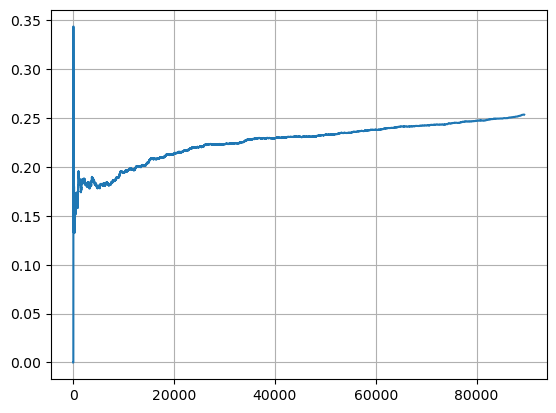

In [54]:
import matplotlib.pyplot as plt

plt.plot(rates)
plt.grid()
plt.show()